In [2]:
import pandas as pd
from collections import Counter, defaultdict

import matplotlib.pyplot as plt


ARCHIVO = 'datos_asociados.csv'

In [3]:
datos = pd.read_csv(ARCHIVO, encoding='utf-8')
datos.shape

(20, 17)

In [4]:
#borrar la columna de marca temporal y sus datos, borrar la linea 12 que esta repetida 
datos = datos.drop(columns=['Marca temporal'])
datos_limpios = datos.drop(index=12)
datos_limpios.shape



(19, 16)

In [5]:
datos_nombres = datos_limpios.rename(columns={
    "Poner las iniciales de su nombre y apellidos": "Nombre",
    "Edad": "Edad",
    "Sexo": "Sexo",
    "Cantón donde vive": "Canton",
    "¿Cuál es su ingreso mensual aproximado?": "Ingreso_Mensual",
    "¿A qué tipo de artesanía se dedica?": "Artesania",
    "¿Cuánto tiempo tiene de emprender?": "Tiempo_Emprender",
    "Cuántas personas trabajan con usted?": "Personas_Trabajan",
    "¿Con qué frecuencia asiste a ferias?": "Frecuencia_Ferias",
    "¿Con qué frecuencia asiste a capacitaciones?": "Frecuencia_Capacitaciones",
    "¿Qué le impide participar en ferias? (puede marcar varias)": "Impedimentos_Ferias",
    "¿Qué le impide participar en capacitaciones? (puede marcar varias)": "Impedimentos_Capacitaciones",
    "Marque cuáles de estas necesidades tiene cubiertas actualmente:": "Necesidades_Cubiertas",
    '¿Considera que sus necesidades básicas están cubiertas?': "Necesidades_Basicas",
    "¿Qué tipo de apoyo le gustaría recibir?": "Apoyo_Deseado",
    "¿Le gustaría participar más en actividades si se mejoran las condiciones?": "Participacion_Actividades"
})
datos_nombres.head(5)

,Nombre,Edad,Sexo,Canton,Ingreso_Mensual,Artesania,Tiempo_Emprender,Personas_Trabajan,Frecuencia_Ferias,Frecuencia_Capacitaciones,Impedimentos_Ferias,Impedimentos_Capacitaciones,Necesidades_Cubiertas,Necesidades_Basicas,Apoyo_Deseado,Participacion_Actividades
0,Melina Mongrut Flores,50,Femenino,Curridabat,Menos de ₡100.000,Bisutería - Joyería,Más de 3 años,Solo yo,Frecuentemente,Aveces,"Falta de dinero, Falta de espacios feriales, F...","Horario poco accesible, Problemas de transport...","Alimentación diaria suficiente, Acceso a agua ...",Parcialmente,Espacios para vender,Sí
1,M.E.B.R,57,Femenino,Alajuelita,Menos de ₡100.000,Gastronomía,Más de 3 años,Solo yo,Aveces,Aveces,"Falta de dinero, Problemas de transporte",Problemas de transporte,Acceso a agua potable,Parcialmente,Apoyo económico,Sí
2,NVAM,21,Femenino,Desamparados,Menos de ₡100.000,"Artículos de mujer, maquillaje, joyeria, cuida...",1 a 3 años,Solo yo,Frecuentemente,Aveces,Falta de espacios feriales,Horario poco accesible,"Alimentación diaria suficiente, Acceso a agua ...",Sí,Publicidad,Sí
3,Felicia Alvarez Méndez,48,Femenino,Vásquez de Coronado,₡100.000 – ₡300.000,Cosmética artesanal y decoraciones diversas,Más de 3 años,Mi familia,Frecuentemente,Frecuentemente,"Problemas de transporte, Falta de espacios fer...",Horario poco accesible,"Acceso a agua potable, Vivienda (techo seguro)...",Parcialmente,Apoyo económico,Sí
4,CPR,43,Femenino,Alajuelita,₡100.000 – ₡300.000,Tarjetería,1 a 3 años,Solo yo,Aveces,Casi nunca,"Problemas de transporte, Cuido de mis hijos. H...",Cuido de mis hijos. Choque de horarios educati...,"Alimentación diaria suficiente, Acceso a agua ...",Parcialmente,Espacios para vender con flexibilidad de horar...,No


In [6]:
#print nombre y edad de cada persona
for index, row in datos_nombres.iterrows():
    print(f"Nombre: {row['Nombre']}, Edad: {row['Edad']}")

Nombre: Melina Mongrut Flores, Edad: 50
Nombre: M.E.B.R, Edad: 57
Nombre: NVAM, Edad: 21
Nombre: Felicia Alvarez Méndez, Edad: 48
Nombre: CPR, Edad: 43
Nombre: AIZJ, Edad: 61
Nombre: Doriam Molina García, Edad: 39
Nombre: BA, Edad: 55
Nombre: JGS, Edad: 38
Nombre: ATM, Edad: 34
Nombre: I L Aguirre Guadamuz, Edad: 60
Nombre: Vanessa Blanco Cascante, Edad: 35
Nombre: Angie BG, Edad: 42
Nombre: Yency Aguilar Chavarria, Edad: 52
Nombre: VGMC, Edad: 37
Nombre: LGAJ, Edad: 53
Nombre: Leila Ureña Bolaños, Edad: 59
Nombre: ACE, Edad: 46
Nombre: Lorena Castro, Edad: 63


In [7]:
#convertir la columna de edad a numeros enteros
datos_nombres['Edad'] = pd.to_numeric(datos_nombres['Edad'], errors='coerce')

#usando if para contar cuantas personas tienen menos de 30 , entre 31 y 40 años, entre 41 y 50 años, entre 51 y 60 años, y mas de 60 años
Menos_de_30 = 0
Entre_31_y_40 = 0
Entre_41_y_50 = 0
Entre_51_y_60 = 0
Mas_de_60 = 0

for index, row in datos_nombres.iterrows():
    if row['Edad'] < 30:
        Menos_de_30 += 1
    elif 31 <= row['Edad'] <= 40:
        Entre_31_y_40 += 1
    elif 41 <= row['Edad'] <= 50:
        Entre_41_y_50 += 1
    elif 51 <= row['Edad'] <= 60:
        Entre_51_y_60 += 1
    else:        Mas_de_60 += 1
print(f"Menos de 30 años: {Menos_de_30}")
print(f"Entre 31 y 40 años: {Entre_31_y_40}")
print(f"Entre 41 y 50 años: {Entre_41_y_50}")
print(f"Entre 51 y 60 años: {Entre_51_y_60}")
print(f"Más de 60 años: {Mas_de_60}")   





Menos de 30 años: 1
Entre 31 y 40 años: 5
Entre 41 y 50 años: 5
Entre 51 y 60 años: 6
Más de 60 años: 2


Counter({'Menos de ₡100.000': 11, '₡100.000 – ₡300.000': 6, 'Más de ₡600.000': 2})


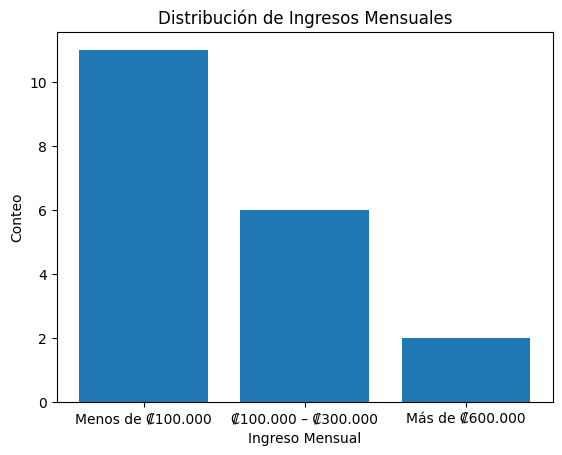

In [8]:
#contar cuantas personas hay por ganancioas mensual
conteo_ingresos = Counter(datos_nombres['Ingreso_Mensual'])
print(conteo_ingresos)
#un grafco de barras con los ingresos mensuales y su conteo usando matplotlib
#agrega etiquetas a los ejes y un titulo
plt.bar(conteo_ingresos.keys(), conteo_ingresos.values())
plt.xlabel('Ingreso Mensual')
plt.ylabel('Conteo')
plt.title('Distribución de Ingresos Mensuales')
plt.show()

In [13]:
#Un ciclo while que permite al usuario realizar consultas múltiples hasta que decida salir, de todas las columnas cada una. muestra el nombre de las columnas para saber que opçion hay que escribir

columnas = datos_nombres.columns.tolist()
print("Columnas disponibles para consulta:")
for columna in columnas:
    print(f"- {columna}")
while True:
    consulta = input("Ingrese el nombre de la columna que desea consultar (o 'salir' para terminar): ")
    if consulta.lower() == 'salir':
        print("¡Hasta luego!")
        break
    elif consulta in columnas:
        conteo = Counter(datos_nombres[consulta])
        print(f"Conteo de valores en la columna '{consulta}':")
        for valor, cantidad in conteo.items():
            print(f"{valor}: {cantidad}")
    else:
        print("Columna no válida. Por favor, intente nuevamente.")
        

Columnas disponibles para consulta:
- Nombre
- Edad
- Sexo
- Canton
- Ingreso_Mensual
- Artesania
- Tiempo_Emprender
- Personas_Trabajan
- Frecuencia_Ferias
- Frecuencia_Capacitaciones
- Impedimentos_Ferias
- Impedimentos_Capacitaciones
- Necesidades_Cubiertas
- Necesidades_Basicas
- Apoyo_Deseado
- Participacion_Actividades
Conteo de valores en la columna 'Edad':
50: 1
57: 1
21: 1
48: 1
43: 1
61: 1
39: 1
55: 1
38: 1
34: 1
60: 1
35: 1
42: 1
52: 1
37: 1
53: 1
59: 1
46: 1
63: 1
¡Hasta luego!


In [10]:
#convertir Participacion_Actividades a booleanos, si la respuesta es "Sí" se convierte a True y se le ofrece: "Contacte a la junta directiva de la asociación", si es "No" se convierte a False, Y se le desea: "Que su emprendimiento florezca de manera prospera"
def convertir_participacion(valor):
    if valor == "Sí":
        print("Contacte a la junta directiva de la asociación")
        return True
    elif valor == "No":
        print("Que su emprendimiento florezca de manera prospera")
        return False
    else:
        return None
    

#aplicar la función a la columna Participacion_Actividades dependiendo del Nombre que escriba el usuario, si el nombre no existe se le dice: "Nombre no encontrado, por favor intente nuevamente"
while True:
    nombre_consulta = input("Ingrese el nombre de la persona para consultar su participación en actividades (o 'salir' para terminar): ")
    if nombre_consulta.lower() == 'salir':
        print("¡Hasta luego!")
        break
    elif nombre_consulta in datos_nombres['Nombre'].values:
        valor_participacion = datos_nombres.loc[datos_nombres['Nombre'] == nombre_consulta, 'Participacion_Actividades'].values[0]
        resultado = convertir_participacion(valor_participacion)
        print(f"Participación en actividades para {nombre_consulta}: {resultado}")
    else:
        print("Nombre no encontrado, por favor intente nuevamente.")
        


¡Hasta luego!


In [11]:
#crea un menu para añadir nuevos datos a la tabla, el menu debe preguntar por cada una de las columnas, presentar las opciones disponibles para cada columna, y al finalizar se debe agregar el nuevo dato a la tabla y guardar los cambios en el archivo csv
def agregar_nuevo_dato():
    nuevo_dato = {}
    for columna in columnas:
        valor = input(f"Ingrese el valor para '{columna}': ")
        nuevo_dato[columna] = valor
    datos_nombres.loc[len(datos_nombres)] = nuevo_dato
    datos_nombres.to_csv(ARCHIVO, index=False, encoding='utf-8')
    print("Nuevo dato agregado y guardado en el archivo CSV.")


while True:    
    opcion = input("¿Desea agregar un nuevo dato? (Sí/No): ")
    if opcion.lower() == 'sí':
        agregar_nuevo_dato()
    elif opcion.lower() == 'no':
        print("¡Hasta luego!")
        break
    else:
        print("Opción no válida. Por favor, intente nuevamente.")
        


¡Hasta luego!


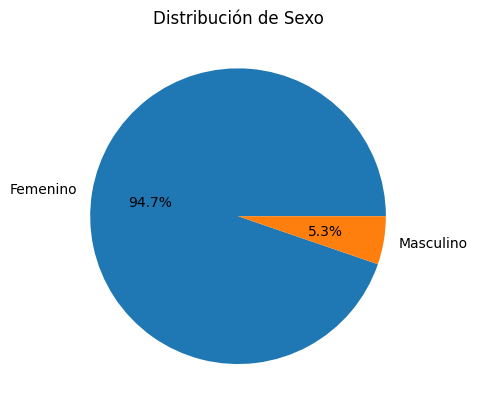

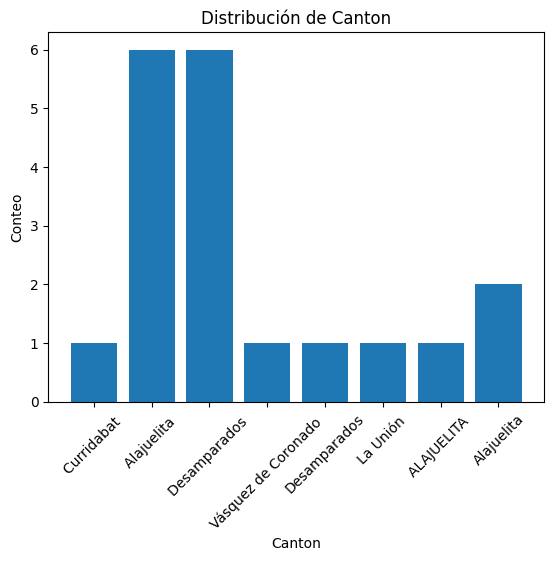

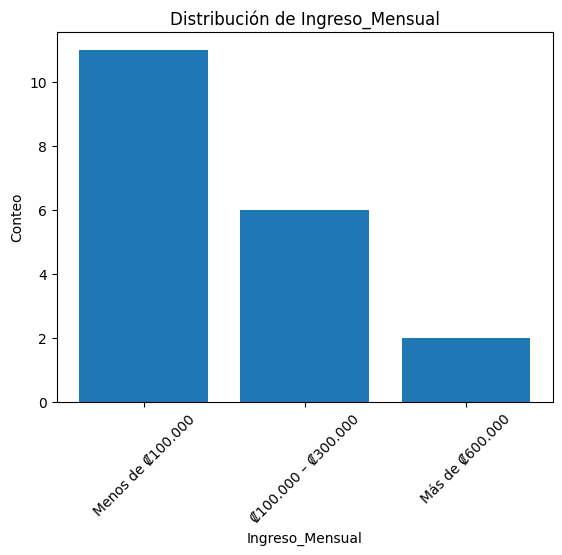

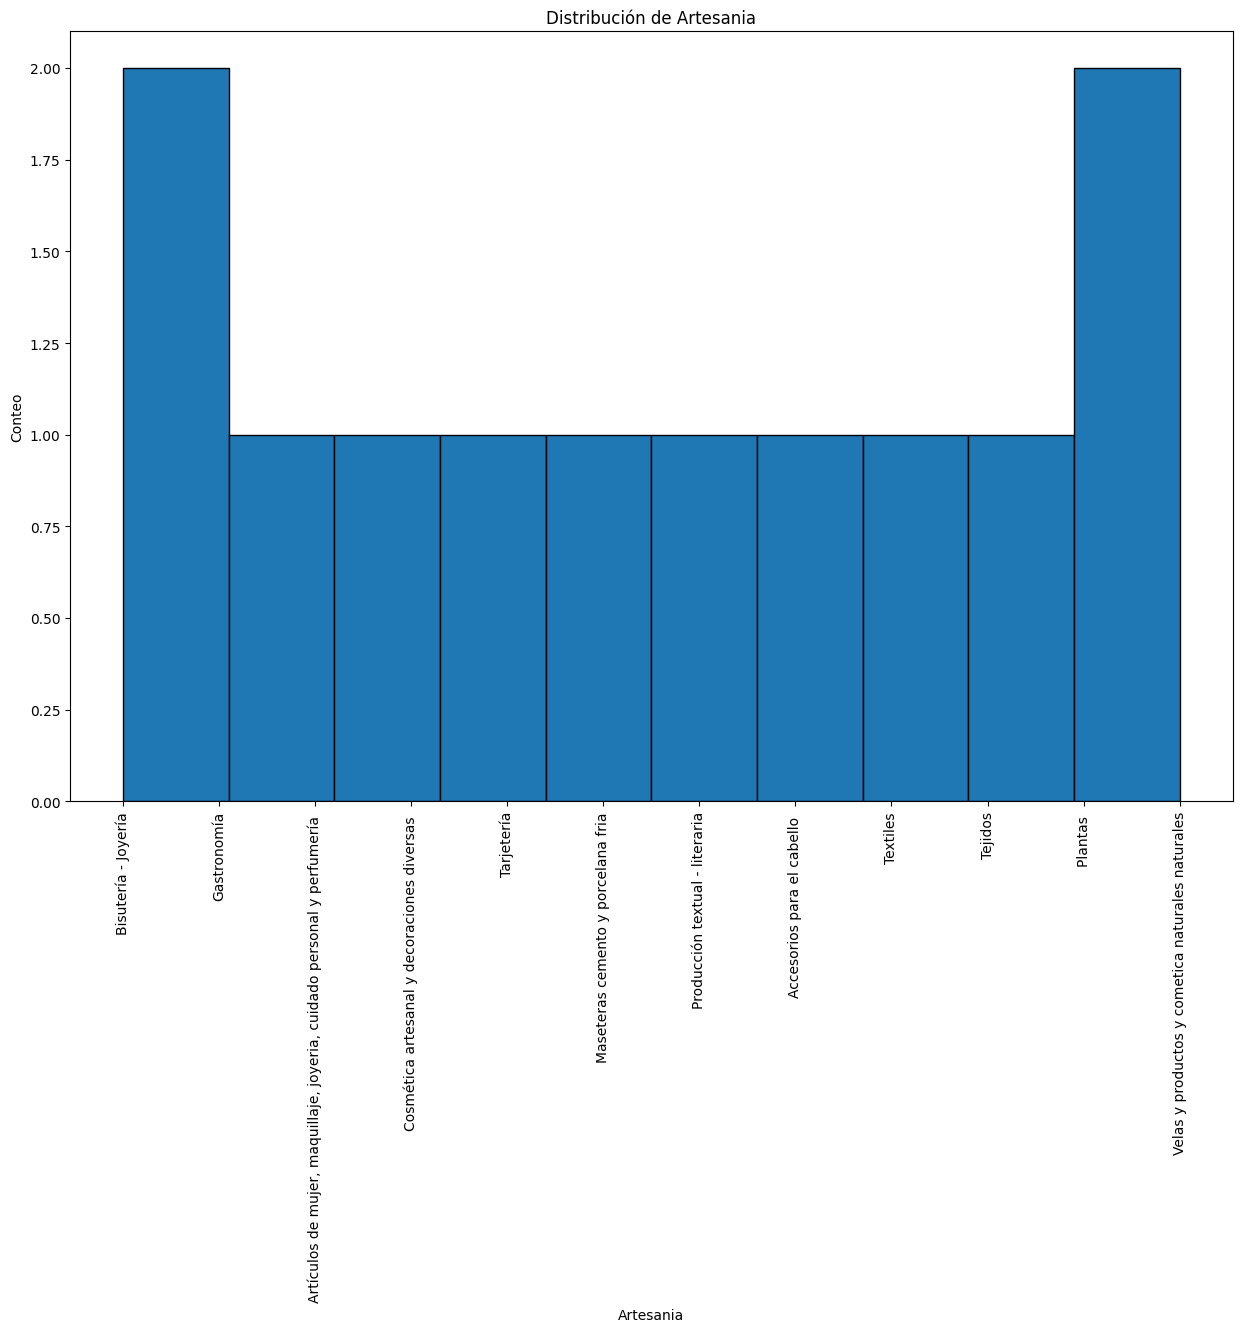

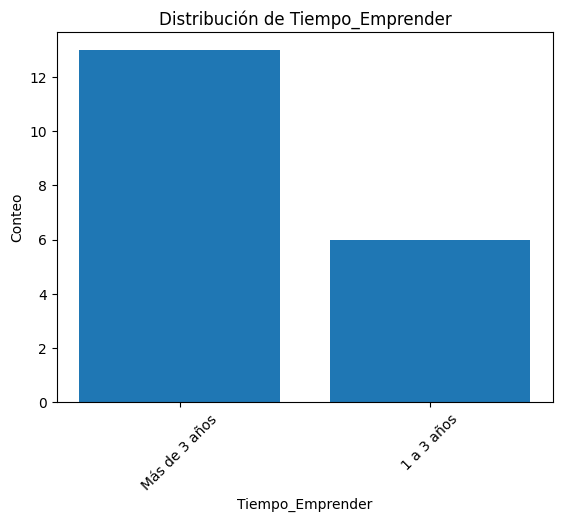

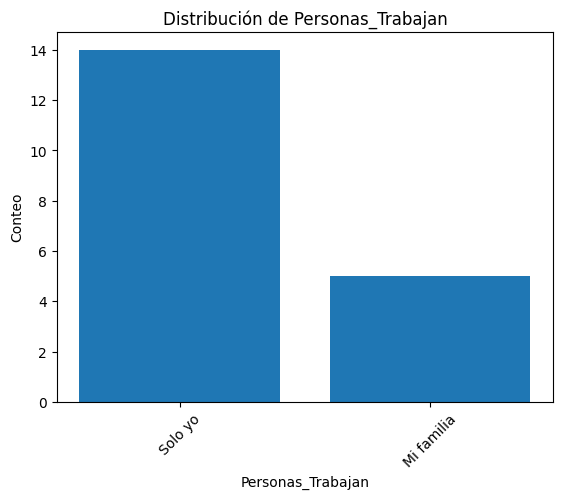

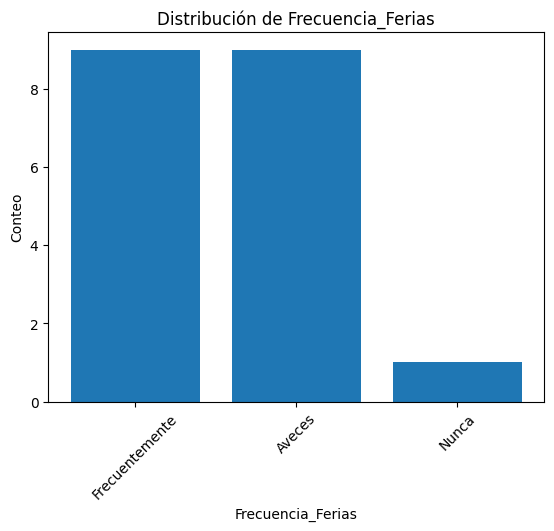

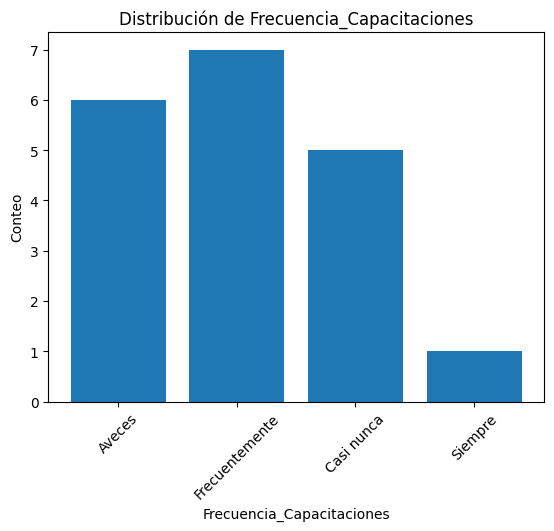

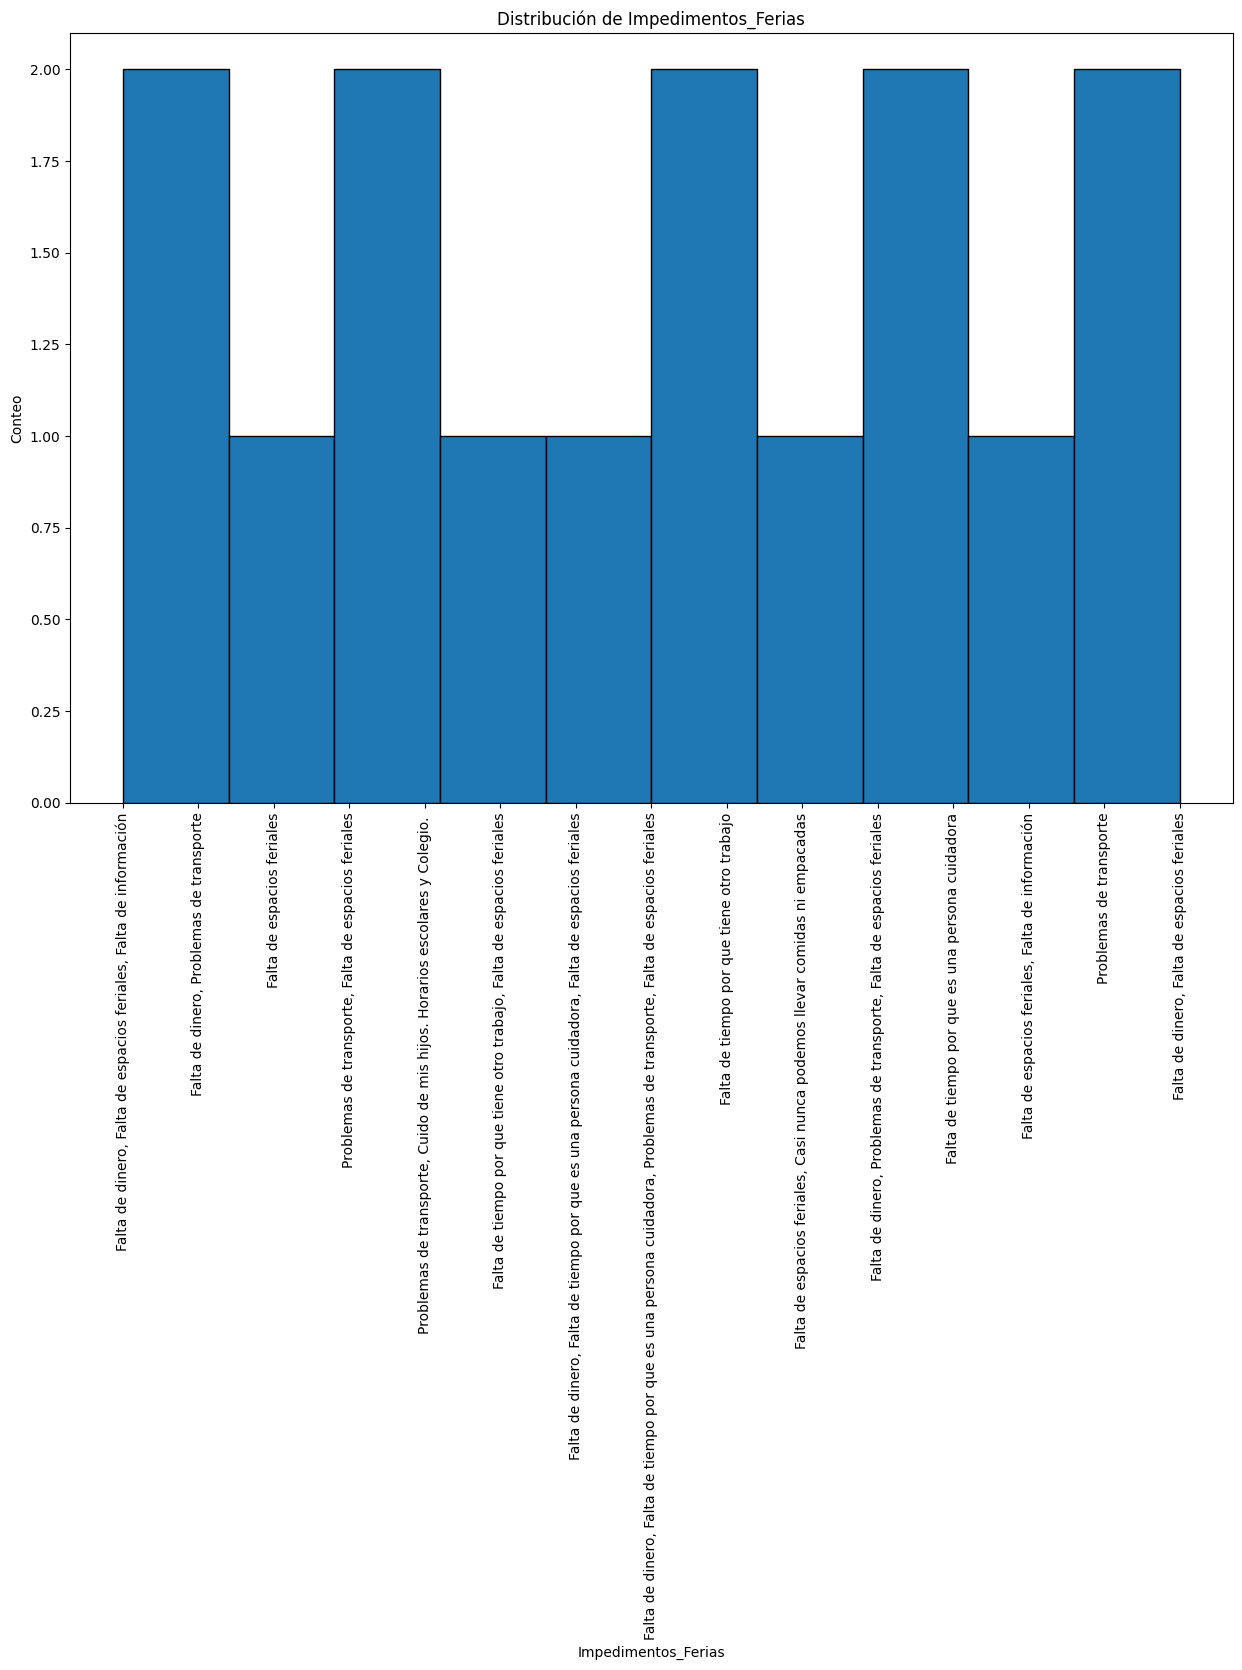

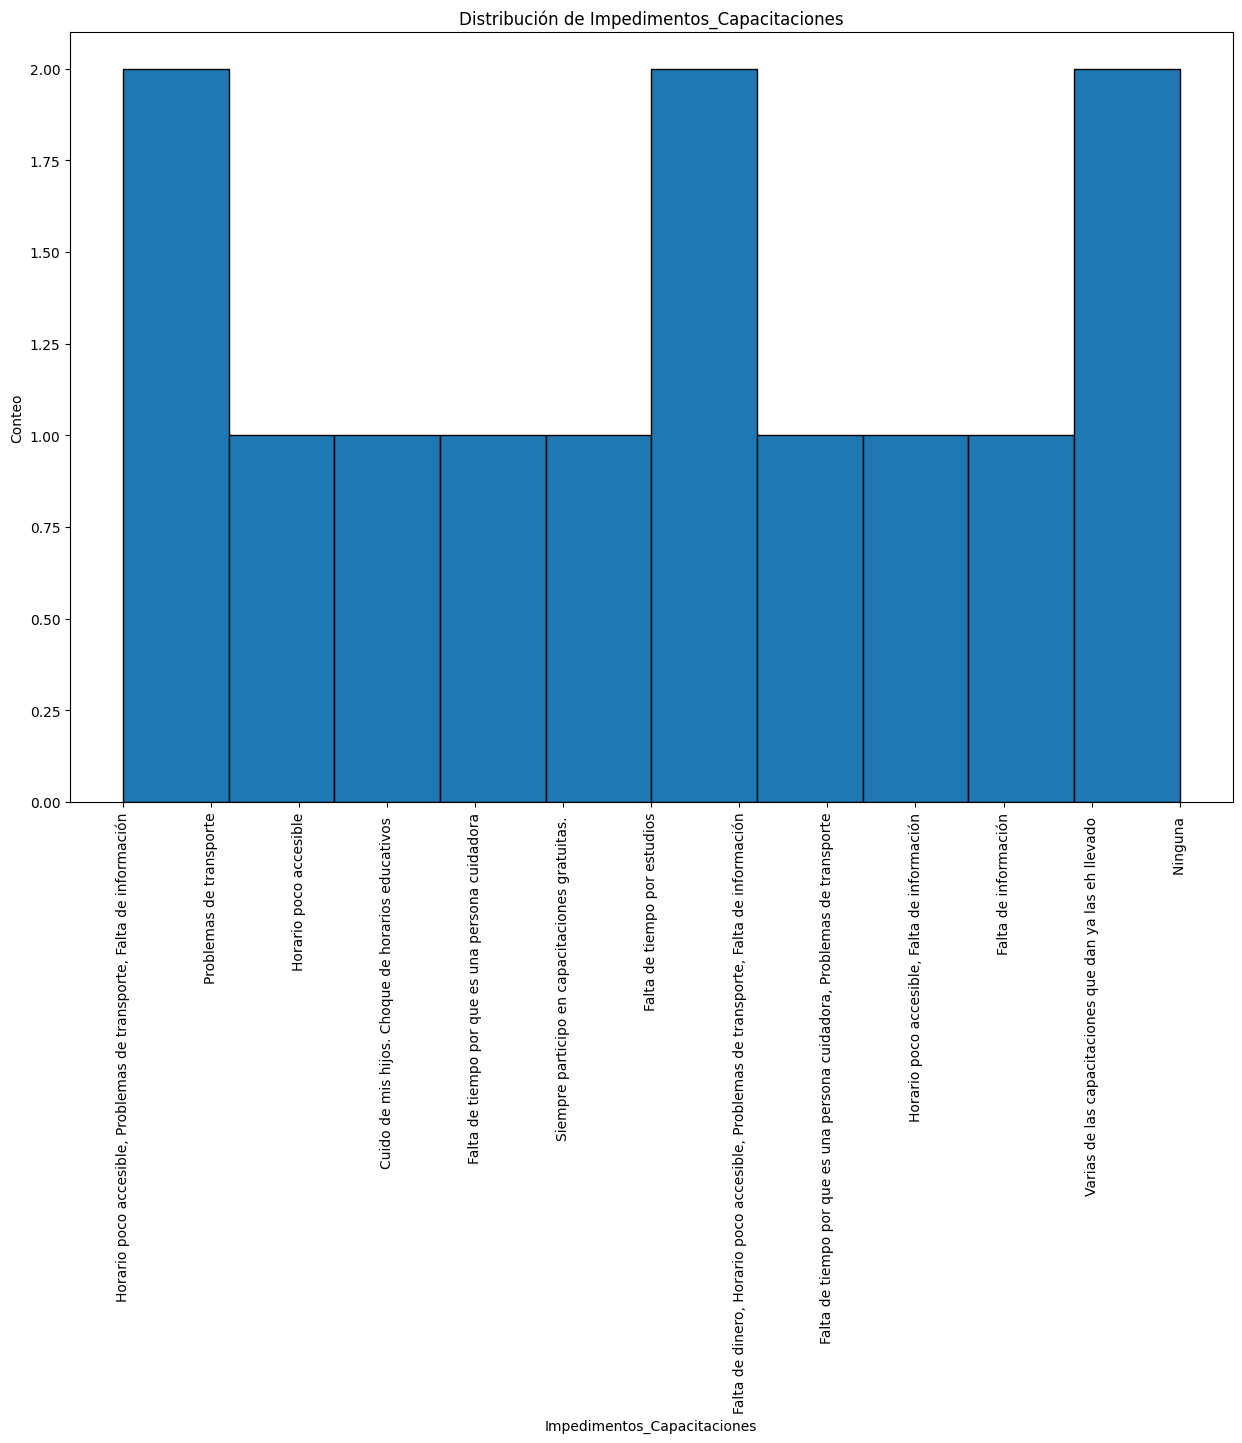

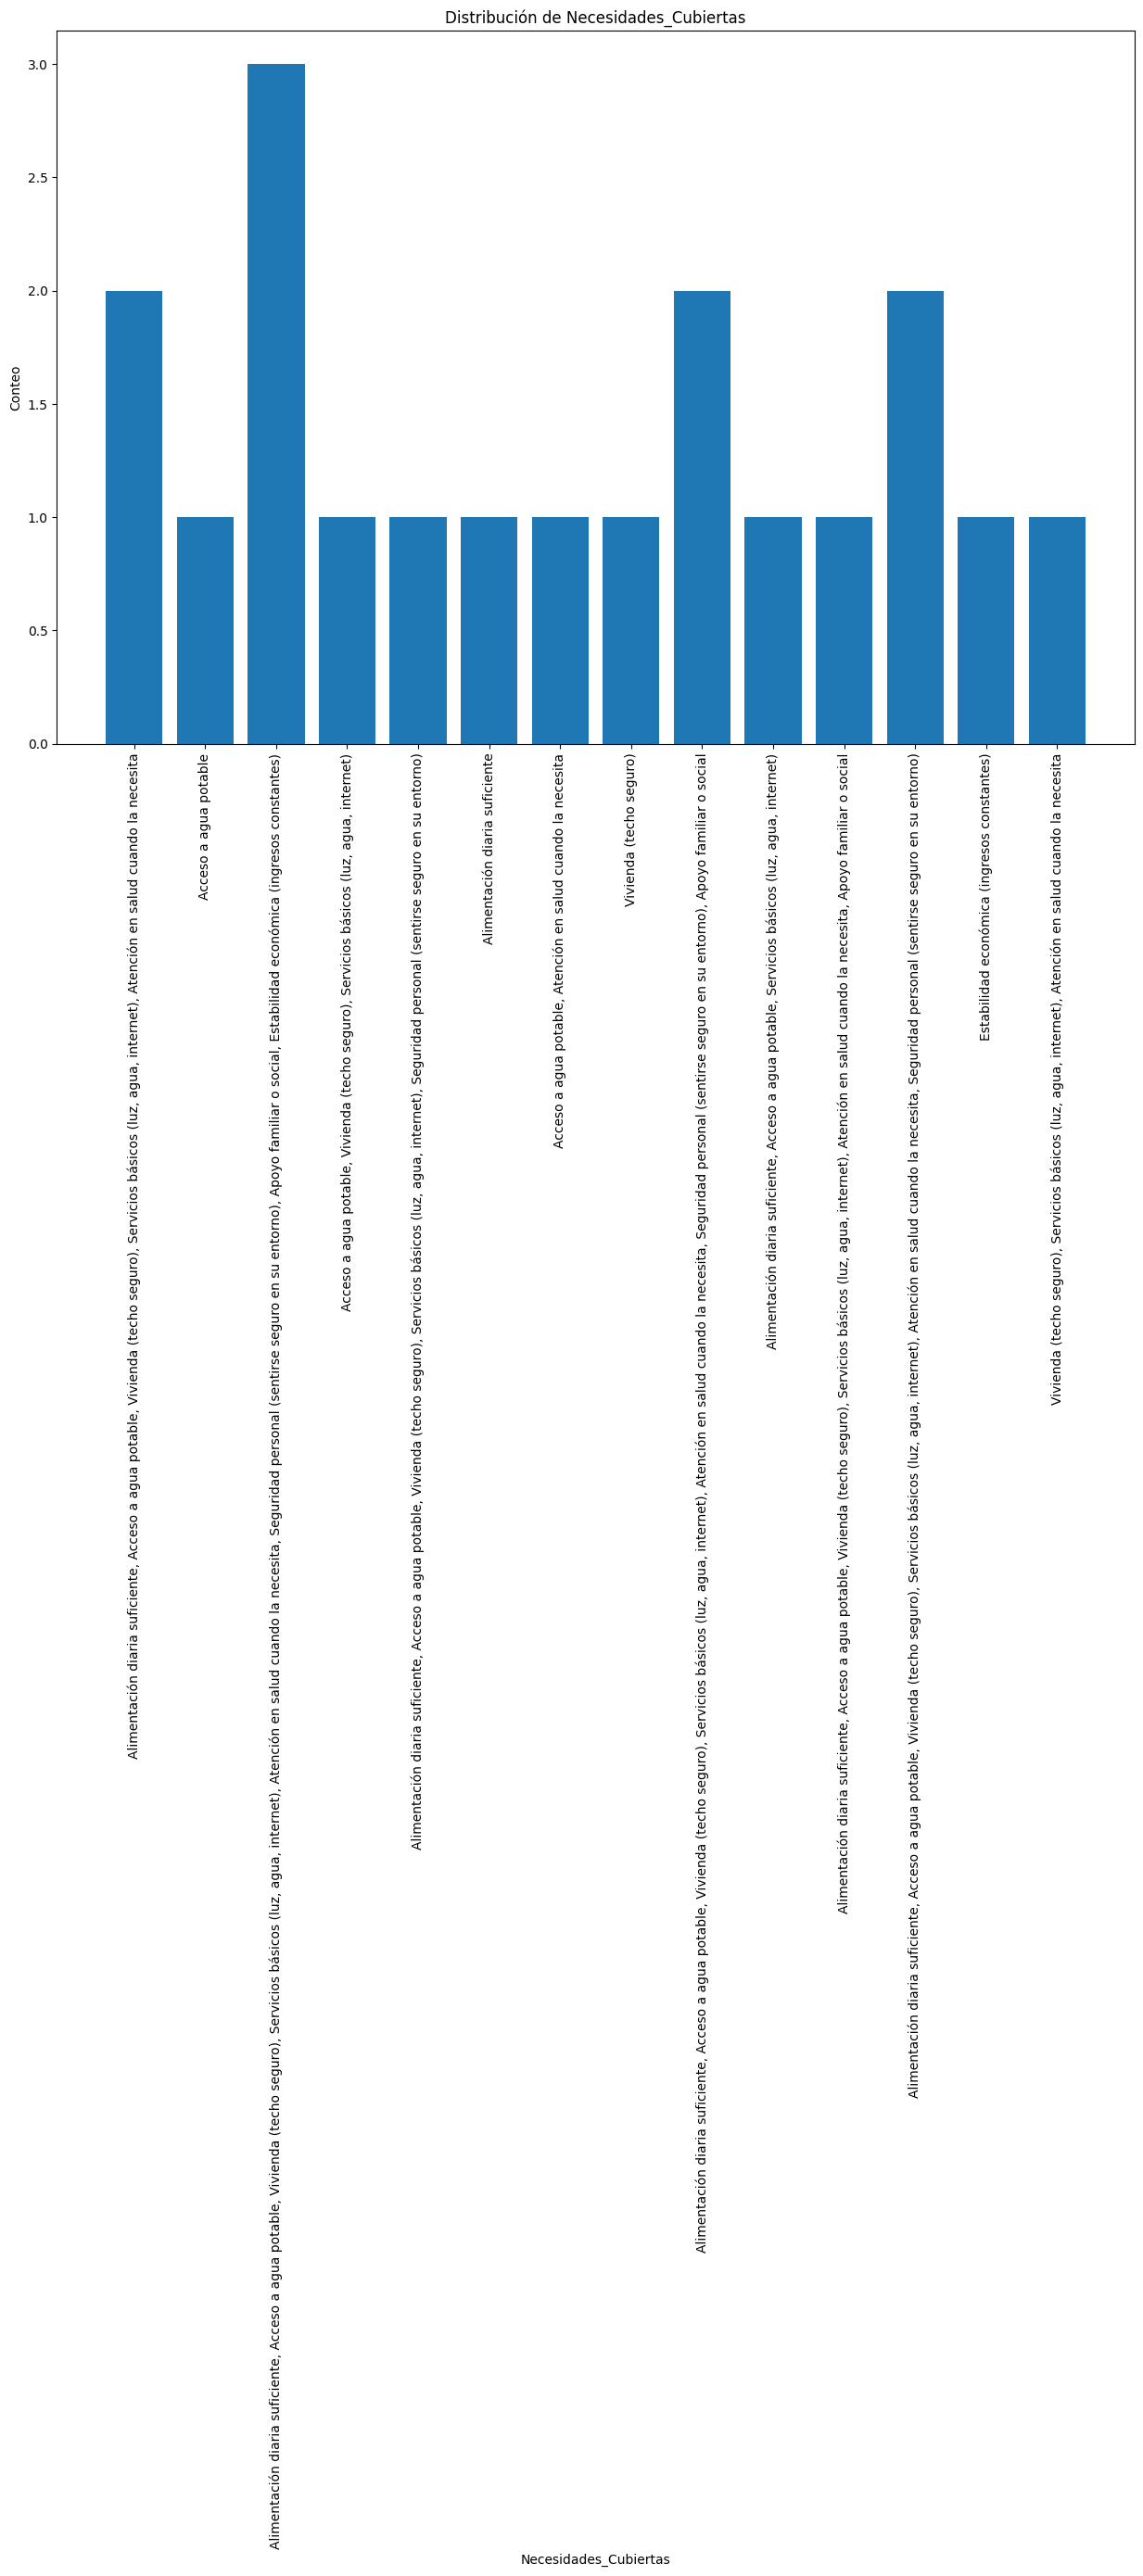

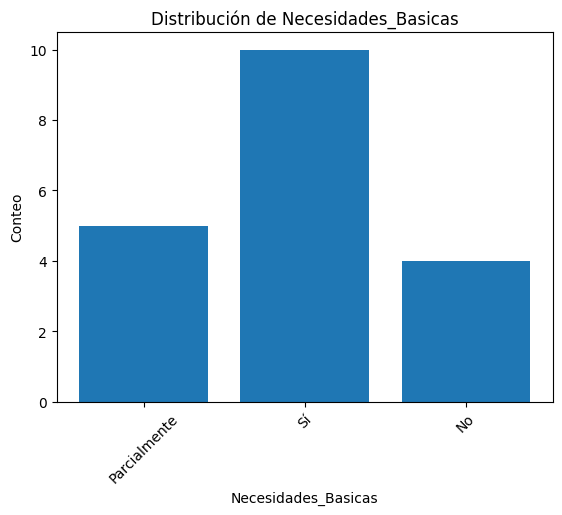

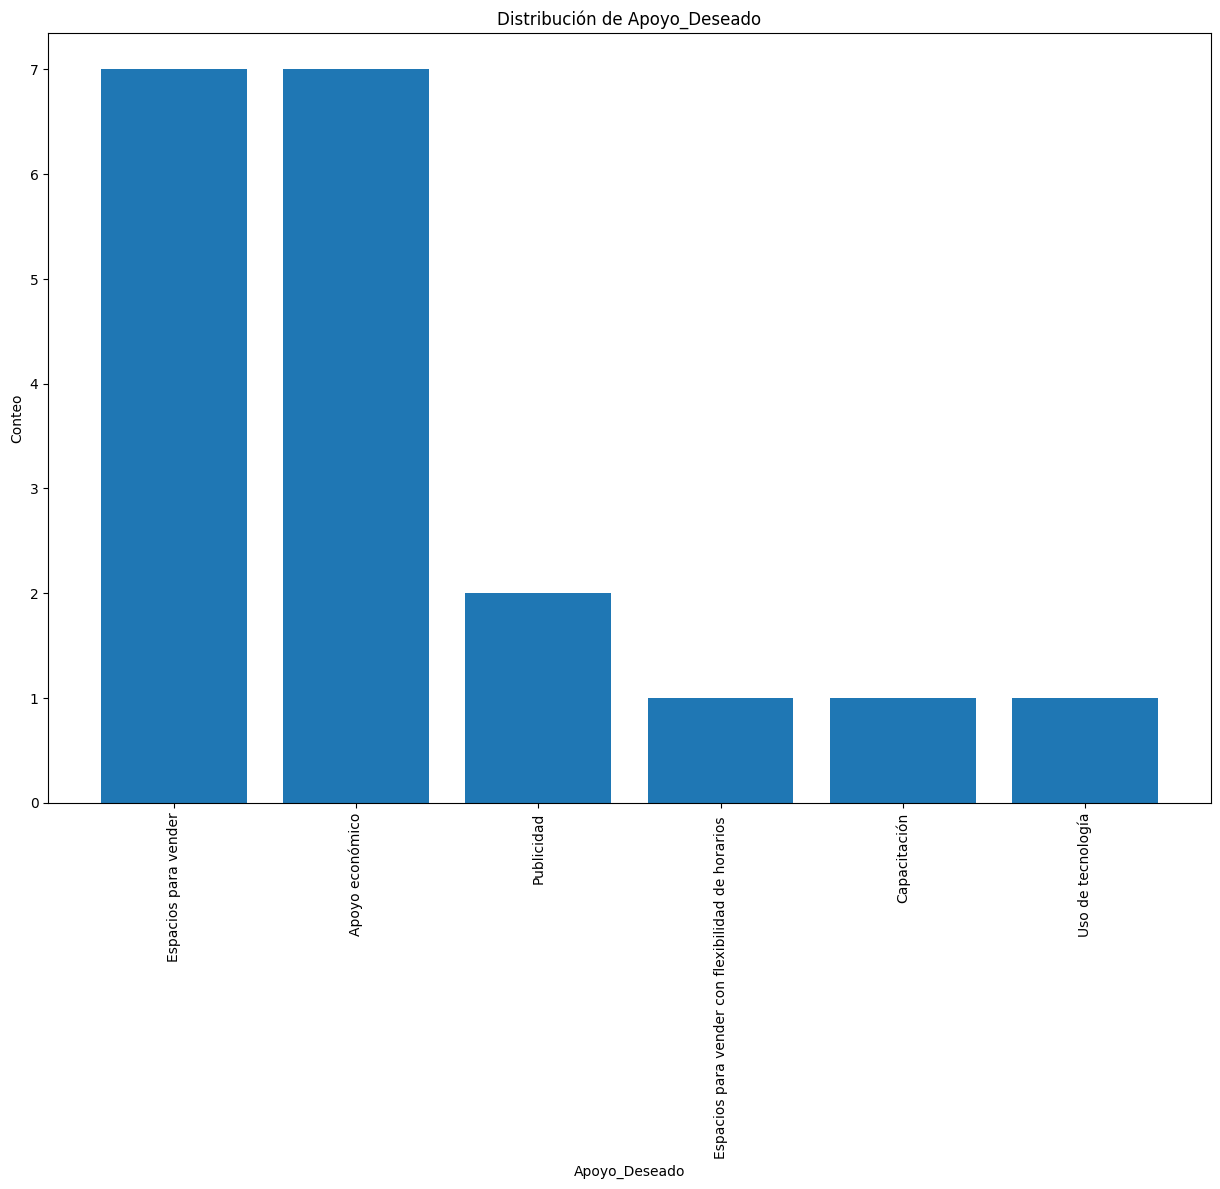

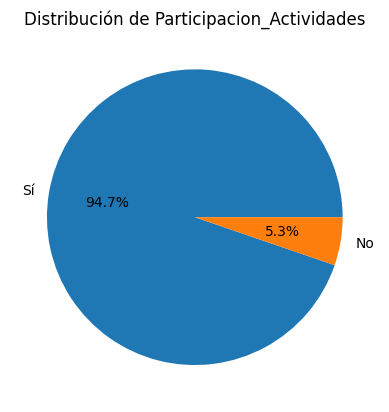

In [12]:
#Crea un grafico para cada columna de la tabla, dependiendo del tipo de dato que tenga cada columna, si es una columna con datos categoricos se hace un grafico de barras, si es una columna con datos numericos se hace un histograma, y si es una columna con datos booleanos se hace un grafico de pastel. Agrega etiquetas a los ejes y un titulo a cada grafico. No uses if, separa cada grafico
#Grafico de pastel para la columna 'Sexo'
conteo_sexo = Counter(datos_nombres['Sexo'])
plt.pie(conteo_sexo.values(), labels=conteo_sexo.keys(), autopct='%1.1f%%')
plt.title('Distribución de Sexo')
plt.xticks(rotation=45)
plt.show()


#Grafico de barras para la columna 'Canton'
conteo_canton = Counter(datos_nombres['Canton'])
plt.bar(conteo_canton.keys(), conteo_canton.values())
plt.xlabel('Canton')
plt.ylabel('Conteo')
plt.title('Distribución de Canton')
plt.xticks(rotation=45)
plt.show()

#Grafico de barras para la columna 'Ingreso_Mensual'
conteo_ingreso_mensual = Counter(datos_nombres['Ingreso_Mensual'])
plt.bar(conteo_ingreso_mensual.keys(), conteo_ingreso_mensual.values())
plt.xlabel('Ingreso_Mensual')
plt.ylabel('Conteo')
plt.title('Distribución de Ingreso_Mensual')
plt.xticks(rotation=45)
plt.show()

#Grafico de histograma para la columna 'Artesania' Alargado para que se vea mejor. Poner la letras verticales para que se vea mejor
conteo_artesania = Counter(datos_nombres['Artesania'])
plt.figure(figsize=(15, 10))
plt.hist(conteo_artesania.keys(), bins=10, edgecolor='black')
plt.xlabel('Artesania')
plt.ylabel('Conteo')
plt.title('Distribución de Artesania')
plt.xticks(rotation=90)
plt.show()

#Grafico de barras para la columna 'Tiempo_Emprender'
conteo_tiempo_emprender = Counter(datos_nombres['Tiempo_Emprender'])
plt.bar(conteo_tiempo_emprender.keys(), conteo_tiempo_emprender.values())
plt.xlabel('Tiempo_Emprender')
plt.ylabel('Conteo')
plt.title('Distribución de Tiempo_Emprender')
plt.xticks(rotation=45)
plt.show()


#Grafico de barras para la columna 'Personas_Trabajan'
conteo_personas_trabajan = Counter(datos_nombres['Personas_Trabajan'])
plt.bar(conteo_personas_trabajan.keys(), conteo_personas_trabajan.values())
plt.xlabel('Personas_Trabajan')
plt.ylabel('Conteo')
plt.title('Distribución de Personas_Trabajan')
plt.xticks(rotation=45)
plt.show()

#Grafico de barras para la columna 'Frecuencia_Ferias'
conteo_frecuencia_ferias = Counter(datos_nombres['Frecuencia_Ferias'])
plt.bar(conteo_frecuencia_ferias.keys(), conteo_frecuencia_ferias.values())
plt.xlabel('Frecuencia_Ferias')
plt.ylabel('Conteo')
plt.title('Distribución de Frecuencia_Ferias')
plt.xticks(rotation=45)
plt.show()

#Grafico de barras para la columna 'Frecuencia_Capacitaciones'
conteo_frecuencia_capacitaciones = Counter(datos_nombres['Frecuencia_Capacitaciones'])
plt.bar(conteo_frecuencia_capacitaciones.keys(), conteo_frecuencia_capacitaciones.values())
plt.xlabel('Frecuencia_Capacitaciones')
plt.ylabel('Conteo')
plt.title('Distribución de Frecuencia_Capacitaciones')
plt.xticks(rotation=45)
plt.show()

#Grafico de histograma para la columna 'Impedimentos_Ferias'
conteo_impedimentos_ferias = Counter(datos_nombres['Impedimentos_Ferias'])
plt.figure(figsize=(15, 10))
plt.hist(conteo_impedimentos_ferias.keys(), bins=10, edgecolor='black')
plt.xlabel('Impedimentos_Ferias')
plt.ylabel('Conteo')
plt.title('Distribución de Impedimentos_Ferias')
plt.xticks(rotation=90)
plt.show()

#Grafico de histograma para la columna 'Impedimentos_Capacitaciones'
conteo_impedimentos_capacitaciones = Counter(datos_nombres['Impedimentos_Capacitaciones'])
plt.figure(figsize=(15, 10))
plt.hist(conteo_impedimentos_capacitaciones.keys(), bins=10, edgecolor='black')
plt.xlabel('Impedimentos_Capacitaciones')
plt.ylabel('Conteo')
plt.title('Distribución de Impedimentos_Capacitaciones')
plt.xticks(rotation=90)
plt.show()

#Grafico de barras para la columna 'Necesidades_Cubiertas'
conteo_necesidades_cubiertas = Counter(datos_nombres['Necesidades_Cubiertas'])
plt.figure(figsize=(15, 10))
plt.bar(conteo_necesidades_cubiertas.keys(), conteo_necesidades_cubiertas.values())
plt.xlabel('Necesidades_Cubiertas')
plt.ylabel('Conteo')
plt.title('Distribución de Necesidades_Cubiertas')
plt.xticks(rotation=90)
plt.show()

#Grafico de barras para la columna 'Necesidades_Basicas'
conteo_necesidades_basicas = Counter(datos_nombres['Necesidades_Basicas'])
plt.bar(conteo_necesidades_basicas.keys(), conteo_necesidades_basicas.values())
plt.xlabel('Necesidades_Basicas')
plt.ylabel('Conteo')
plt.title('Distribución de Necesidades_Basicas')
plt.xticks(rotation=45)
plt.show()

#Grafico de barras para la columna 'Apoyo_Deseado'
conteo_apoyo_deseado = Counter(datos_nombres['Apoyo_Deseado'])
plt.figure(figsize=(15, 10))
plt.bar(conteo_apoyo_deseado.keys(), conteo_apoyo_deseado.values())
plt.xlabel('Apoyo_Deseado')
plt.ylabel('Conteo')
plt.title('Distribución de Apoyo_Deseado')
plt.xticks(rotation=90)
plt.show()

#Grafico de pastel para la columna 'Participacion_Actividades'
conteo_participacion_actividades = Counter(datos_nombres['Participacion_Actividades'])
plt.pie(conteo_participacion_actividades.values(), labels=conteo_participacion_actividades.keys(), autopct='%1.1f%%')
plt.title('Distribución de Participacion_Actividades')
plt.show()


